<table style="width: 100%; border: none;">
    <tr style="border: none;">
        <td style="width: 30%; border: none; text-align: left;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Logo_de_la_UPTC.svg/960px-Logo_de_la_UPTC.svg.png" alt="Logo UPTC" width="250"/>
        </td>
        <td style="width: 70%; border: none; text-align: center;">
            <h3 style="margin: 0; padding: 2px;">Especialización en Analítica Estratégica de Datos</h3>
            <h4 style="margin: 0; padding: 2px; font-weight: normal;">Modelos Analíticos</h4>
            <h3 style="margin: 0; padding: 5px;">Entregable # 1</h3>
        </td>
    </tr>
</table>

**Profesor:** Johan Diaz

**Estudiantes:**

- Gabriela VIllalobos
- Marco Diaz
- Ivan Mariño
- Diego Reyes

In [ ]:
!pip install ydata_profiling scikit_posthocs -q
import pandas as pd
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ydata_profiling import ProfileReport
from pathlib import Path
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
from sklearn.model_selection import train_test_split

 ## 1. Dataset previo

## 1.1. Resumen dataset original

| Nombre | Tipo | Tipo de variable | Descripción |
|---|---|---|---|
| viatico_id | int | Identificador | Un identificador único para cada registro de gastos de viaje o «viático». |
| commission_request_id | int | Identificador | Un identificador único para la solicitud de comisión o reembolso asociada al gasto de viaje. |
| total_travel_allowance | float | Cuantitativa continua | El importe total de la asignación de viaje o del reembolso del gasto. |
| purpose | string | Cualitativa nominal | La categoría o clasificación del motivo o razón del gasto de viaje. |
| full_date | date | Cualitativa ordinal | La fecha completa en el formato AAAA-MM-DD de inicio del viaje. |
| commission_days | int | Cuantitativa discreta | El número de días durante los cuales se incurrió en el gasto de viaje. |
| employee_position_norm | string | Cualitativa nominal | La versión normalizada y estandarizada del cargo o puesto del empleado. |
| position_level | int | Cualitativa ordinal | Un indicador del nivel jerárquico del empleado dentro de la organización. |
| city_origin | string | Cualitativa nominal | La ciudad de origen de la ruta de transporte. |
| city_destination_main | string | Cualitativa nominal | La ciudad de destino principal de la ruta de transporte. |
| distance_km | float | Cuantitativa continua | Distancia en kilómetros entre la ciudad de origen y destino. |
| destination_count | int | Cuantitativa discreta | El número de ciudades de destino a lo largo de la ruta. |
| is_contractor | boolean | Cualitativa nominal dicotómica | Un indicador que señala si el empleado es un contratista o un empleado a tiempo completo. |  

<br>

Este conjunto de datos recopila información sobre la gestión, asignación y reembolso de viáticos y gastos de viaje del personal de la Registraduría. Estructurado a nivel de registro único por viático o solicitud de comisión, el dataset integra variables financieras (como el monto total otorgado), temporales (fecha de inicio y días de duración) y cualitativas que explican el motivo del viaje. Incluye información sociolaboral clave sobre el perfil del empleado (cargo normalizado, nivel jerárquico y si es contratista o planta) junto con especificaciones logísticas y geográficas de las rutas atendidas, como las ciudades de origen y destino, la distancia recorrida en kilómetros y el total de destinos visitados. Ya que para actividades previas se solicitaba un histórico de al menos 3 años e inicialmente solo se poseían registro de un añó se decidió ampliar usando un LLM, por lo que, el origen del dataset es real y sintetico.

In [ ]:
registraduriaDatasetOriginal = pd.read_csv('/content/registraduria_database_clean.csv')

## Reporte de datos dataset original
profile = ProfileReport(
    registraduriaDatasetOriginal,
    title="Reporte Calidad Datos"
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 28.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Los principales hallazgos del informe de perfil inicial nos permiten ver cuántos datos hay en el conjunto de datos: 15.753. También vemos que hay 5 variables categóricas y 6 numéricas en un total de 13 columnas.

**Correlación:** Al principio, vemos una correlación fuerte (0.552) entre la cantidad de días que dura la comisión y el valor total del viaje. También encontramos una relación fuerte entre las columnas relacionadas con el cargo, su nivel y el tipo de contrato.

**Valores nulos:** Encontramos 1.282 valores nulos en la columna “Nivel de cargo". Estos valores nulos corresponden a contratistas y otros, ya que sus perfiles no están estrictamente asociados a un nivel jerárquico.

**Calidad de datos:** En la columna de valores totales de los viajes, encontramos 416 valores en 0, aunque el valor de días de comisión es positivo (mayor a 0). Esto indica un problema de calidad de datos y una oportunidad para mejorar la recolección de información. Sin embargo, no es un dato muy representativo en comparación con el total de datos.

## 1.2. Mejora del dataset original

**Teniendo en cuenta las recomendaciones de clase para mejorar el dataset y generar más datos se usó un LLM (Claude Snnet 4.6) para complementar el dataset original, usando inicialmente esl siguiente prompt:**

> Actúa como un experto en ciencia de datos y análisis de datos gubernamentales. Tengo un dataset de viáticos de la Registraduría Nacional (gastos de viaje y desplazamiento de funcionarios públicos). Este dataset será utilizado en una clase de machine learning donde debo aplicar:
>
> Modelo de predicción (regresión): predecir valores numéricos (ej. monto total del viático).
Modelo de clasificación: clasificar instancias en categorías (ej. tipo de viático, nivel de gasto).
Modelo de agrupación (clustering): identificar patrones o segmentos naturales en los datos.
>
> Requisitos y contexto:
>
> El dataset contiene columnas como: fecha de viaje, destino, cargo del funcionario, monto del viático, duración del viaje, tipo de transporte, etc. (si tienes más detalles, por favor compártelos).
Necesito recomendaciones de nuevas columnas derivadas que sean útiles para los tres tipos de modelos.
Las nuevas columnas deben ser realistas y relevantes para el análisis de viáticos.
Prioriza columnas que aporten valor predictivo, discriminativo o de agrupamiento.
>
> Formato de respuesta:
>
> Lista numerada de columnas sugeridas.
Para cada columna: nombre sugerido, breve descripción, cómo se calcularía, y para qué tipo de modelo(s) sería más útil.
Incluye al menos 5 recomendaciones.
Si es posible, menciona consideraciones de calidad de datos o transformaciones necesarias*

**Obteniendo la siguiente respuesta:**

>Con base en todo lo analizado, aquí está el resumen consolidado de todas las columnas propuestas, organizadas por origen:
>
> ### Columnas derivadas de datos existentes
>
>| # | Nombre | Descripción corta | Modelos |
>| :--- | :--- | :--- | :--- |
>| 1 | `daily_allowance_rate` | Monto del viático dividido entre días de comisión | R · C · K |
>| 2 | `allowance_per_km` | Costo total dividido entre la distancia recorrida | R · C · K |
>| 3 | `travel_month` / `travel_quarter` | Mes y trimestre extraídos de la fecha de viaje | R · C · K |
>| 4 | `is_fiscal_year_end` | Indicador si la comisión ocurrió en nov-dic | R · C · K |
>| 5 | `is_weekend_departure` | Indicador si el viaje inició en fin de semana | R · C |
>| 6 | `spending_tier` | Nivel de gasto (Bajo / Medio / Alto / Muy Alto) por cuartiles | C · K |
>| 7 | `destination_region` | Región natural de Colombia del destino (Andina, Caribe, etc.) | R · C · K |
>| 8 | `position_seniority_index` | Índice combinado de nivel jerárquico y tipo de vinculación | R · K |
>| 9 | `purpose_expense_profile` | Target Encoding del propósito según media histórica de gasto | R · K |
>| 10 | `is_multi_destination` / `multi_dest_cost_ratio` | Indicador de viajes a múltiples municipios y costo por destino | C · K |
>| 11 | `log_total_allowance` | Transformación logarítmica del monto (target para regresión) | R |
>
> <br>
>
>### Columnas nuevas (datos sintéticos / enriquecimiento externo)
>
>| # | Nombre | Descripción corta | Modelos |
>| :--- | :--- | :--- | :--- |
>| 1 | `transport_mode` | Modo de transporte: Aéreo, Terrestre, Fluvial, Mixto | R · C · K |
>| 2 | `accommodation_type` | Categoría del hospedaje según nivel jerárquico y duración | R · C · K |
>| 3 | `prior_authorizations_required` | Número de aprobaciones institucionales requeridas (1-3) | C · K |
>| 4 | `destination_security_level` | Nivel de riesgo de orden público del municipio destino | R · C · K |
>| 5 | `had_travel_incidents` | Si ocurrió alguna novedad operativa durante el viaje | C · K |
>| 6 | `department_budget_execution_pct` | % del presupuesto de viáticos ejecutado por el área a esa fecha | R · K |
>| 7 | `functional_area` | Dependencia interna del funcionario (TI, Jurídica, Electoral, etc.) | R · C · K |
>| 8 | `return_trip_included` | Si el viático cubre explícitamente el tiquete de regreso | R · C |
>| 9 | `advance_booking_days` | Días de anticipación con que se gestionó la comisión | R · K |
>| 10 | `requires_per_diem` | Si aplica reconocimiento de gastos de manutención diaria | R · C |
>
>**Referencia rápida** — R: Regresión · C: Clasificación · K: Clustering
>
>De las 21 columnas totales, **12 sirven para los tres modelos simultáneamente**, lo que las convierte en la base recomendada del dataset enriquecido. ¿Arrancamos con el script de generación?

**Se procedió con el siguiente prompt para obtener un dataset mejorado:**

> Basándote en el archivo CSV que te proporcioné anteriormente, agrega las siguientes variables que recomendaste en nuestra conversación previa. Asegúrate de que los valores de estas nuevas variables sean realistas y coherentes con los datos existentes en el CSV. Para cada variable, proporciona una breve explicación de cómo derivaste los valores a partir de los datos originales. El resultado debe ser una tabla actualizada en formato CSV, incluyendo las columnas originales y las nuevas. Verifica que no haya valores inconsistentes con el contexto del dataset. Amplia el dataset (más filas) siguiendo la misma logica

Respuesta:

> ### Dataset completo listo
>
>El conjunto de datos ha sido consolidado y enriquecido con éxito. A continuación se presenta el resumen estructural del archivo final:
>
> **Archivo:** `registraduria_database_full.csv`
> **Volumen:** 25.753 filas × 37 columnas
> **Composición:** 13 variables originales + 10 sintéticas + 14 nuevas columnas derivadas.
>
> ---
>
> ### Lógica de las nuevas columnas derivadas
>
> | # | Nombre de la columna | Lógica y descripción | Comportamiento en el dataset |
> | :--- | :--- | :--- | :--- |
> | **1** | `daily_allowance_rate` | `total_travel_allowance / commission_days` | Normaliza el gasto por día. Rango: $0 → $1.6M. |
> | **2** | `allowance_per_km` | `total_travel_allowance / (distance_km + 1)` | Costo por kilómetro. El `+1` evita errores de división por cero en comisiones locales. |
> | **3** | `travel_month`<br>`travel_quarter`<br>`travel_year` | Extraídos directamente de `full_date` con `.dt` | Identifican dinámicas temporales. Años presentes: 2022–2025. |
> | **4** | `is_fiscal_year_end` | `1` si el viaje ocurrió en noviembre o diciembre | Representa los meses de cierre presupuestal. El 13.1% del dataset cae en este periodo. |
> | **5** | `is_weekend_departure` | `1` si `full_date` cae en sábado o domingo | Captura el 30% de las comisiones. Dato clave para detectar gastos atípicos de fin de semana. |
> | **6** | `spending_tier` | Cuartiles calculados sobre `total_travel_allowance` | **Bajo** (<P25: $556K), **Medio-Bajo**, **Medio-Alto** y **Alto** (>P75: $1.5M). Clases perfectamente balanceadas (~3.940 c/u) — *ideal como target de clasificación.* |
> | **7** | `destination_region` | Mapeo manual de los 644 destinos a las 6 regiones naturales de Colombia | Distribución: Andina 73%, Caribe 13%, Pacífica 7%, Orinoquía 3%, Amazonía 3%, Insular 1%. |
> | **8** | `position_seniority_index` | `(5 - position_level) × (1 - is_contractor × 0.5)` | Índice de jerarquía: Nivel 1 = 4 puntos (máximo); los contratistas reciben el 50% del peso respecto al personal de planta. |
> | **9** | `purpose_expense_profile`| Media histórica de `total_travel_allowance` agrupada por `purpose` | Equivale a un *Target Encoding* global. Rango: $0 → $1.35M según el tipo de comisión. |
>  **10**| `is_multi_destination` | `1` si `destination_count > 1` | Identifica rutas complejas. Representa solo el 6.9% del dataset, útil como feature discriminativo. |
> | **11**| `multi_dest_cost_ratio` | `total_travel_allowance / destination_count` | Normaliza el costo económico por municipio visitado. |
> | **12**| `log_total_allowance` | `log1p(total_travel_allowance)` | Transformación logarítmica que corrige el sesgo positivo en la distribución del monto (Rango: 0 → 15.97). *Úsala como target en el modelo de regresión.* |


# 2. Entendimiento del Dataset Mejorado

In [ ]:
## Cargar el dataset
data_path = "/content/registraduria_database_completo.csv"
registraduriaDataset = pd.read_csv(data_path)

## Convertir la fecha directamente
registraduriaDataset["full_date"] = pd.to_datetime(registraduriaDataset["full_date"], format="%Y-%m-%d")

## Esquema de datos
tipos_datos = {
    # Enteros
    "travel_month": "Int8",
    "travel_quarter": "Int8",
    "travel_year": "Int16",
    "destination_count": "Int8",
    "advance_booking_days": "Int8",
    "prior_authorizations_required": "Int8",
    "position_level": "Int8",

    # Binarios
    "is_contractor": "Int8",
    "is_fiscal_year_end": "Int8",
    "is_weekend_departure": "Int8",
    "is_multi_destination": "Int8",
    "had_travel_incidents": "Int8",
    "return_trip_included": "Int8",
    "requires_per_diem": "Int8",

    # Categóricas
    "city_origin": "category",
    "city_destination_main": "category",
    "employee_position_norm": "category",
    "purpose": "category",
    "transport_mode": "category",
    "accommodation_type": "category",
    "destination_security_level": "category",
    "destination_region": "category",
    "spending_tier": "category",
    "functional_area": "category"
}

## Aplicar los tipos de datos al DataFrame
registraduriaDataset = registraduriaDataset.astype(tipos_datos)

## 2.1. Shape y variables categóricas/numéricas

In [ ]:
print(f"Datos cargados: {registraduriaDataset.shape[0]} filas x {registraduriaDataset.shape[1]} columnas")
registraduriaDataset.head()

## Tipos de datos

num_auto = registraduriaDataset.select_dtypes(include="number").columns.tolist()
cat_auto = registraduriaDataset.select_dtypes(exclude="number").columns.tolist()

print("Numericas detectadas :", num_auto)
print("Categoricas detectadas:", cat_auto)

Datos cargados: 25753 filas x 37 columnas


,viatico_id,commission_request_id,total_travel_allowance,purpose,full_date,commission_days,employee_position_norm,position_level,city_origin,city_destination_main,...,travel_year,is_fiscal_year_end,is_weekend_departure,spending_tier,destination_region,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
0,1,2201097,1610649,Visitas de Supervisión Contractual,2022-01-09,1.5,GERENTE,2,BOGOTA D.C.,MANIZALES,...,2022,0,1,Alto,Andina,3.0,1107880.82,0,1610649.0,14.292148
1,19213,2407237,1996416,Visitas de Control Técnico,2022-01-14,2.5,PROFESIONAL,3,BOGOTA D.C.,GRANADA,...,2022,0,0,Alto,Orinoquía,2.0,1183522.00,0,1996416.0,14.506865
2,4,2203264,549239,Visitas de Supervisión Contractual,2022-01-21,1.5,PROFESIONAL,3,BOGOTA D.C.,CUCUTA,...,2022,0,0,Bajo,Andina,2.0,1107880.82,0,549239.0,13.216291
3,16667,2404691,1738955,Visitas de Supervisión Contractual,2022-01-21,1.5,CONTRALOR,1,BOGOTA D.C.,ARAUCA,...,2022,0,0,Alto,Orinoquía,4.0,1107881.00,0,1738955.0,14.368795
4,2,2201941,443812,Visitas de Supervisión Contractual,2022-01-21,0.5,GERENTE,2,BOGOTA D.C.,MEDELLIN,...,2022,0,0,Bajo,Andina,3.0,1107880.82,0,443812.0,13.003159


Numericas detectadas : ['viatico_id', 'commission_request_id', 'total_travel_allowance', 'commission_days', 'position_level', 'distance_km', 'destination_count', 'is_contractor', 'prior_authorizations_required', 'had_travel_incidents', 'dept_budget_execution_pct', 'return_trip_included', 'advance_booking_days', 'requires_per_diem', 'daily_allowance_rate', 'allowance_per_km', 'travel_month', 'travel_quarter', 'travel_year', 'is_fiscal_year_end', 'is_weekend_departure', 'position_seniority_index', 'purpose_expense_profile', 'is_multi_destination', 'multi_dest_cost_ratio', 'log_total_allowance']
Categoricas detectadas: ['purpose', 'full_date', 'employee_position_norm', 'city_origin', 'city_destination_main', 'transport_mode', 'accommodation_type', 'destination_security_level', 'functional_area', 'spending_tier', 'destination_region']


## 2.2. Estadisticas Descriptivas

Desde este paso vemos que hay incoherencias en los datos:
- *total_travel_allowance:* contiene ceros, es inconsistente que un gasto de viaje sea cero.
- *distance_km:* contiene ceros, es inconsistente que la distancia de viaje sea cero.
- *daily_allowance_rate:* contiene ceros, de la misma manera que con el gasto de viaje no tiene sentido que el gato diario sea cero.
- *allowance_per_km:* contiene ceros.
- *multi_dest_cost_ratio:* contiene ceros.
- *log_total_travel_allowance:* contiene ceros.

In [ ]:
## Estadísticas descriptivas numéricas
registraduriaDataset.describe().round(2)

,viatico_id,commission_request_id,total_travel_allowance,full_date,commission_days,position_level,distance_km,destination_count,is_contractor,prior_authorizations_required,...,travel_month,travel_quarter,travel_year,is_fiscal_year_end,is_weekend_departure,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
count,25753.00,25753.00,25753.00,25753,25753.00,25753.0,25753.00,25753.0,25753.0,25753.0,...,25753.0,25753.0,25753.0,25753.0,25753.0,25753.00,25753.00,25753.0,25753.00,25753.00
mean,13046.05,2001656.10,1100012.79,2024-02-14 14:32:57.462819840,2.67,2.82,407.83,1.1,0.04,2.0,...,7.03,2.67,2023.58,0.13,0.29,2.14,1086420.19,0.07,1045172.71,13.05
min,1.00,1025.00,0.00,2022-01-09 00:00:00,0.50,1.0,0.00,1.0,0.0,1.0,...,1.0,1.0,2022.0,0.0,0.0,0.50,0.00,0.0,0.00,0.00
25%,6530.00,2202386.00,554259.00,2023-04-01 00:00:00,1.50,3.0,110.15,1.0,0.0,1.0,...,4.0,2.0,2023.0,0.0,0.0,2.00,1107880.82,0.0,517654.00,13.23
50%,13078.00,2401108.00,1014545.00,2024-03-25 00:00:00,2.50,3.0,314.02,1.0,0.0,2.0,...,7.0,3.0,2024.0,0.0,0.0,2.00,1107881.00,0.0,963596.00,13.83
75%,19563.00,2407587.00,1554628.00,2025-02-17 00:00:00,3.50,3.0,603.47,1.0,0.0,3.0,...,10.0,4.0,2025.0,0.0,1.0,2.00,1183521.55,0.0,1505364.00,14.26
max,26001.00,2414025.00,11219738.00,2025-12-31 00:00:00,15.00,4.0,6817.43,6.0,1.0,3.0,...,12.0,4.0,2025.0,1.0,1.0,4.00,1350710.40,1.0,11219738.00,16.23
std,7514.08,811432.11,770362.51,NaN,1.55,0.55,424.42,0.42,0.19,0.74,...,2.96,1.02,1.08,0.34,0.46,0.59,191337.94,0.26,730009.86,3.00


# Estadísticas descriptivas categóricas
El principal hayasgo resultado de este analisis de variables categoricas es que existen demasiadas categorias para city_destination_main por lo cual, dependiendo del analisis que queremos hacer, tal vez sería mas eficiente usar la variable destination_region.

Adicionalmente:
- Las ciudades de origen y destino mas freciuentes son Bogotá y Medellin respectivamente, lo cual tiene sentido teniendo en cuenta la importancia economica y politica de dichas ciudades.
- La mayoría de funcionarios que piden viaticos son profesionales del area de control interno se trasladan por via terrestre a locaciones de bajo riesgo y se hospedan en hoteles tres estrellas.

In [ ]:
## Estadísticas descriptivas categóricas
registraduriaDataset.select_dtypes(exclude="number", include=['category']).describe()

,purpose,employee_position_norm,city_origin,city_destination_main,transport_mode,accommodation_type,destination_security_level,functional_area,spending_tier,destination_region
count,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753
unique,11,8,32,644,4,4,3,7,4,6
top,Visitas de Supervisión Contractual,PROFESIONAL,BOGOTA D.C.,MEDELLIN,Terrestre,Hotel 3 estrellas,Bajo riesgo,Control Interno,Alto,Andina
freq,15632,20053,15243,918,12269,16151,16835,12004,6707,18916


In [ ]:
## Valores unicos por columna
registraduriaDataset.nunique().sort_values(ascending=False)

,0
viatico_id,25753
commission_request_id,24002
allowance_per_km,23082
total_travel_allowance,21836
multi_dest_cost_ratio,21817
log_total_allowance,21807
daily_allowance_rate,21606
distance_km,10601
dept_budget_execution_pct,8671
full_date,1376


In [ ]:
# Valores unicos por columna con sus tipos
print("Tipos de variables unicas DATASET accidentes")
registraduriaDataset.apply(pd.unique).to_frame(name='Variables unicas')

Tipos de variables unicas DATASET accidentes


,Variables unicas
viatico_id,"[1, 19213, 4, 16667, 2, 3, 5, 24637, 6, 7, 8, ..."
commission_request_id,"[2201097, 2407237, 2203264, 2404691, 2201941, ..."
total_travel_allowance,"[1610649, 1996416, 549239, 1738955, 443812, 13..."
purpose,"['Visitas de Supervisión Contractual', 'Visita..."
full_date,"[2022-01-09T00:00:00.000000000, 2022-01-14T00:..."
commission_days,"[1.5, 2.5, 0.5, 4.5, 1.0, 2.0, 3.5, 8.0, 5.5, ..."
employee_position_norm,"['GERENTE', 'PROFESIONAL', 'CONTRALOR', 'DIREC..."
position_level,"[2, 3, 1, 4]"
city_origin,"['BOGOTA D.C.', 'SINCELEJO', 'IBAGUE', 'MOCOA'..."
city_destination_main,"['MANIZALES', 'GRANADA', 'CUCUTA', 'ARAUCA', '..."


## 2.3. Diccionario de Variables — Viáticos RNEC

| Variable | Tipo | Descripción | Valores |
|---|---|---|---|
| `viatico_id` | Int64 | Identificador único del registro de viático | — |
| `commission_request_id` | Int64 | Identificador único de la solicitud de comisión | — |
| `full_date` | Date | Fecha de inicio de la comisión | YYYY-MM-DD |
| `travel_month` | Int8 | Mes del viaje | 1–12 |
| `travel_quarter` | Int8 | Trimestre del viaje | 1–4 |
| `travel_year` | Int16 | Año del viaje | 2022–2025 |
| `is_fiscal_year_end` | Int8 | 1 si la comisión ocurrió en noviembre o diciembre | 0 / 1 |
| `is_weekend_departure` | Int8 | 1 si el viaje inició en sábado o domingo | 0 / 1 |
| `commission_days` | Float32 | Duración de la comisión en días | 0.5, 1.0, 1.5… |
| `distance_km` | Float32 | Distancia en kilómetros al destino principal | ≥ 0 |
| `destination_count` | Int8 | Número de municipios visitados | 1–6 |
| `advance_booking_days` | Int8 | Días de anticipación con que se gestionó la solicitud | 1–25 |
| `city_origin` | Categorical | Municipio de origen del funcionario | — |
| `city_destination_main` | Categorical | Municipio de destino principal | — |
| `transport_mode` | Enum | Modo de transporte utilizado | Aéreo · Terrestre · Fluvial · Mixto |
| `return_trip_included` | Int8 | 1 si el viático cubre el tiquete de regreso | 0 / 1 |
| `is_multi_destination` | Int8 | 1 si la comisión involucra más de un municipio | 0 / 1 |
| `total_travel_allowance` | Int64 | Monto total del viático en pesos colombianos | ≥ 0 |
| `daily_allowance_rate` | Float64 | Costo promedio del viático por día | ≥ 0 |
| `allowance_per_km` | Float64 | Costo del viático por kilómetro recorrido | ≥ 0 |
| `multi_dest_cost_ratio` | Float64 | Costo promedio por destino visitado | ≥ 0 |
| `log_total_allowance` | Float64 | Transformación logarítmica del monto total | ≥ 0 |
| `purpose_expense_profile` | Float64 | Media histórica del monto por propósito (Target Encoding) | ≥ 0 |
| `dept_budget_execution_pct` | Float32 | Porcentaje del presupuesto de viáticos ejecutado por el área | 0.0–1.0 |
| `spending_tier` | Enum | Nivel de gasto clasificado por cuartiles | Bajo · Medio-Bajo · Medio-Alto · Alto |
| `requires_per_diem` | Int8 | 1 si la comisión tiene derecho a manutención diaria | 0 / 1 |
| `employee_position_norm` | Categorical | Cargo normalizado del funcionario | — |
| `position_level` | Int8 | Nivel jerárquico del funcionario | 1 (alto) – 4 (bajo) |
| `position_seniority_index` | Float32 | Índice combinado de jerarquía y tipo de vinculación | 0.5–4.0 |
| `is_contractor` | Int8 | 1 si el funcionario es contratista | 0 / 1 |
| `prior_authorizations_required` | Int8 | Número de aprobaciones institucionales requeridas | 1–3 |
| `functional_area` | Enum | Dependencia interna del funcionario | Registro Civil · Identificación · Organización Electoral · Infraestructura TI · Jurídica · Administrativa · Control Interno |
| `destination_region` | Enum | Región natural de Colombia del destino | Andina · Caribe · Pacífica · Orinoquía · Amazonía · Insular |
| `destination_security_level` | Enum | Nivel de riesgo de orden público del destino | Bajo riesgo · Riesgo medio · Alto riesgo |
| `accommodation_type` | Enum | Categoría del hospedaje utilizado | Hotel 4-5 estrellas · Hotel 3 estrellas · Hospedaje económico · Sin alojamiento |
| `had_travel_incidents` | Int8 | 1 si ocurrió alguna novedad operativa durante el viaje | 0 / 1 |
| `purpose` | Categorical | Motivo oficial de la comisión | Visitas de Control Técnico · Visitas de Supervisión Contractual · Innovación y Eficiencia Pública · Optimización de Redes LAN · Cobro Coactivo · Seguimiento a Sentencias · Capacitación Institucional · Ceremonias de Reconocimiento · Eventos Culturales y Bienestar · Planificación y Control Fiscal · Comunicación y Transparencia Territorial |

## 2.4. Distribución de todas las variables

Se encontro que:
- Variables como *total_travel_allowance, distance_km, daily_allowance_rate, multi_dest_cost_ratio* y *log_total_allowance* tienen colas bastante pesadas a la derecha.
- La distribución de *dept_budget_execution_pct* parece ser bimodal posiblemente por la existencia de subpoblaciones (el comportamiento de ejecución del presupuesto de los departamentos en la Registraduría puede ser diferente).
- Según *travel_month* parece haber dos picos de la pedida de comisión de viáticos en Abril y Septiembre.

<Figure size 600x400 with 0 Axes>

(array([855., 857., 852., 854., 852., 852., 857., 860., 842., 856., 856.,
        852., 857., 849., 848., 857., 856., 852., 855., 867., 866., 867.,
        867., 866., 867., 867., 866., 867., 867., 867.]),
 array([1.00000000e+00, 8.67666667e+02, 1.73433333e+03, 2.60100000e+03,
        3.46766667e+03, 4.33433333e+03, 5.20100000e+03, 6.06766667e+03,
        6.93433333e+03, 7.80100000e+03, 8.66766667e+03, 9.53433333e+03,
        1.04010000e+04, 1.12676667e+04, 1.21343333e+04, 1.30010000e+04,
        1.38676667e+04, 1.47343333e+04, 1.56010000e+04, 1.64676667e+04,
        1.73343333e+04, 1.82010000e+04, 1.90676667e+04, 1.99343333e+04,
        2.08010000e+04, 2.16676667e+04, 2.25343333e+04, 2.34010000e+04,
        2.42676667e+04, 2.51343333e+04, 2.60010000e+04]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de viatico_id')

Text(0.5, 0, 'viatico_id')

Text(0, 0.5, 'Frecuencia')

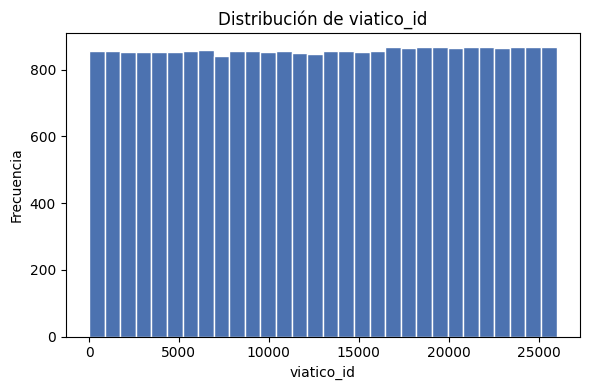

<Figure size 600x400 with 0 Axes>

(array([ 1187.,  1124.,  1210.,   560.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,  3816.,  3895., 13961.]),
 array([1.02500000e+03, 8.14583333e+04, 1.61891667e+05, 2.42325000e+05,
        3.22758333e+05, 4.03191667e+05, 4.83625000e+05, 5.64058333e+05,
        6.44491667e+05, 7.24925000e+05, 8.05358333e+05, 8.85791667e+05,
        9.66225000e+05, 1.04665833e+06, 1.12709167e+06, 1.20752500e+06,
        1.28795833e+06, 1.36839167e+06, 1.44882500e+06, 1.52925833e+06,
        1.60969167e+06, 1.69012500e+06, 1.77055833e+06, 1.85099167e+06,
        1.93142500e+06, 2.01185833e+06, 2.09229167e+06, 2.17272500e+06,
        2.25315833e+06, 2.33359167e+06, 2.41402500e+06]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de commission_request_id')

Text(0.5, 0, 'commission_request_id')

Text(0, 0.5, 'Frecuencia')

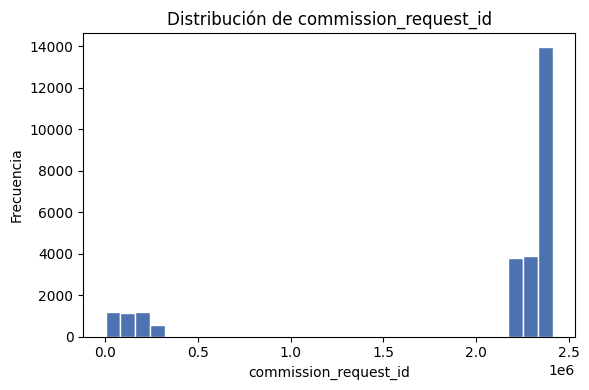

<Figure size 600x400 with 0 Axes>

(array([4.502e+03, 4.861e+03, 5.090e+03, 4.198e+03, 3.647e+03, 1.683e+03,
        8.380e+02, 4.250e+02, 2.230e+02, 1.100e+02, 6.300e+01, 3.800e+01,
        3.000e+01, 2.000e+01, 1.200e+01, 6.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([       0.        ,   373991.26666667,   747982.53333333,
         1121973.8       ,  1495965.06666667,  1869956.33333333,
         2243947.6       ,  2617938.86666667,  2991930.13333333,
         3365921.4       ,  3739912.66666667,  4113903.93333333,
         4487895.2       ,  4861886.46666667,  5235877.73333333,
         5609869.        ,  5983860.26666667,  6357851.53333333,
         6731842.8       ,  7105834.06666667,  7479825.33333333,
         7853816.6       ,  8227807.86666667,  8601799.13333333,
         8975790.4       ,  9349781.66666667,  9723772.93333333,
        10097764.2       , 10471755.4666666

Text(0.5, 1.0, 'Distribución de total_travel_allowance')

Text(0.5, 0, 'total_travel_allowance')

Text(0, 0.5, 'Frecuencia')

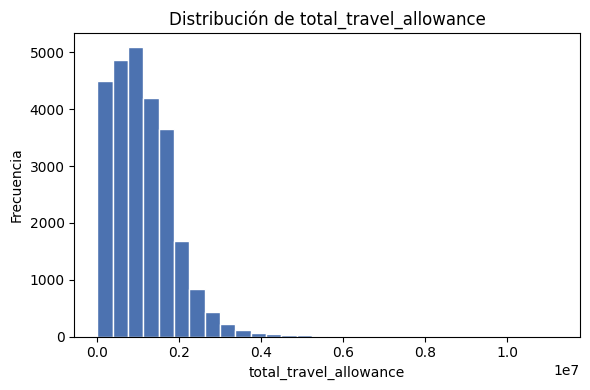

<Figure size 600x400 with 0 Axes>

(array([1.163e+03, 1.467e+03, 7.056e+03, 7.140e+02, 6.633e+03, 5.840e+02,
        3.127e+03, 5.360e+02, 2.921e+03, 7.210e+02, 1.670e+02, 1.530e+02,
        1.400e+01, 8.800e+01, 7.000e+00, 1.060e+02, 1.200e+01, 1.320e+02,
        0.000e+00, 9.800e+01, 0.000e+00, 0.000e+00, 0.000e+00, 1.300e+01,
        0.000e+00, 2.100e+01, 5.000e+00, 0.000e+00, 0.000e+00, 1.500e+01]),
 array([ 0.5       ,  0.98333333,  1.46666667,  1.95      ,  2.43333333,
         2.91666667,  3.4       ,  3.88333333,  4.36666667,  4.85      ,
         5.33333333,  5.81666667,  6.3       ,  6.78333333,  7.26666667,
         7.75      ,  8.23333333,  8.71666667,  9.2       ,  9.68333333,
        10.16666667, 10.65      , 11.13333333, 11.61666667, 12.1       ,
        12.58333333, 13.06666667, 13.55      , 14.03333333, 14.51666667,
        15.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de commission_days')

Text(0.5, 0, 'commission_days')

Text(0, 0.5, 'Frecuencia')

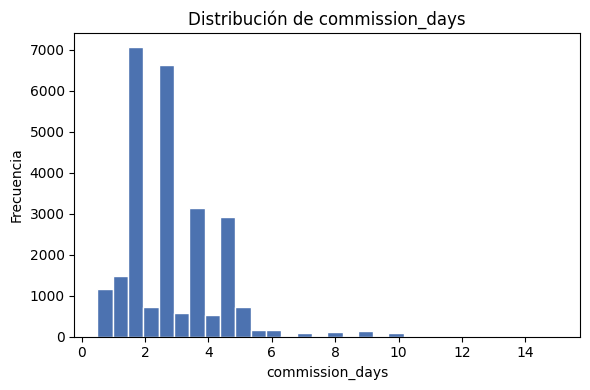

<Figure size 600x400 with 0 Axes>

(array([ 1783.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  1205.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0., 22578.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,   187.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
        2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5,
        3.6, 3.7, 3.8, 3.9, 4. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de position_level')

Text(0.5, 0, 'position_level')

Text(0, 0.5, 'Frecuencia')

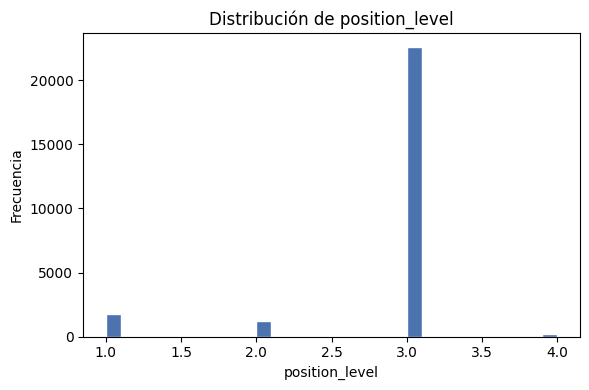

<Figure size 600x400 with 0 Axes>

(array([1.0903e+04, 5.7320e+03, 3.5570e+03, 2.3010e+03, 2.7860e+03,
        3.6000e+02, 5.7000e+01, 8.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.1000e+01, 4.0000e+00, 4.0000e+00, 2.8000e+01]),
 array([   0.        ,  227.24760333,  454.49520667,  681.74281   ,
         908.99041333, 1136.23801667, 1363.48562   , 1590.73322333,
        1817.98082667, 2045.22843   , 2272.47603333, 2499.72363667,
        2726.97124   , 2954.21884333, 3181.46644667, 3408.71405   ,
        3635.96165333, 3863.20925667, 4090.45686   , 4317.70446333,
        4544.95206667, 4772.19967   , 4999.44727333, 5226.69487667,
        5453.94248   , 5681.19008333, 5908.43768667, 6135.68529   ,
        6362.93289333, 6590.18049667, 6817.4281    ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de distance_km')

Text(0.5, 0, 'distance_km')

Text(0, 0.5, 'Frecuencia')

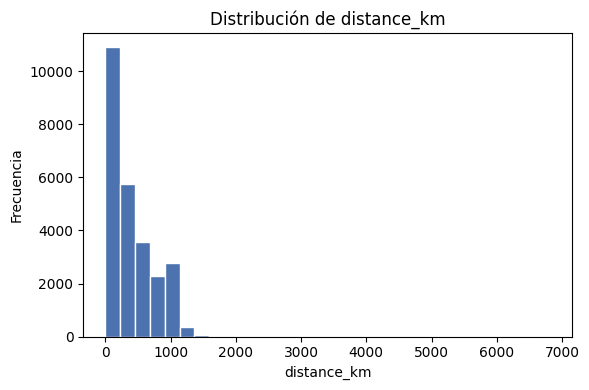

<Figure size 600x400 with 0 Axes>

(array([2.3947e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.3140e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.8200e+02, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.6300e+02, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.1000e+01,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.6000e+01]),
 array([1.        , 1.16666667, 1.33333333, 1.5       , 1.66666667,
        1.83333333, 2.        , 2.16666667, 2.33333333, 2.5       ,
        2.66666667, 2.83333333, 3.        , 3.16666667, 3.33333333,
        3.5       , 3.66666667, 3.83333333, 4.        , 4.16666667,
        4.33333333, 4.5       , 4.66666667, 4.83333333, 5.        ,
        5.16666667, 5.33333333, 5.5       , 5.66666667, 5.83333333,
        6.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de destination_count')

Text(0.5, 0, 'destination_count')

Text(0, 0.5, 'Frecuencia')

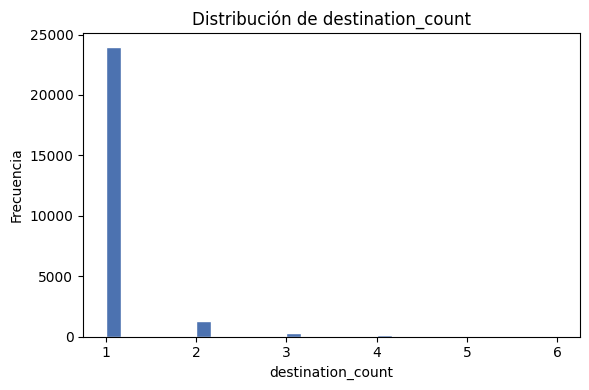

<Figure size 600x400 with 0 Axes>

(array([24801.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,   952.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de is_contractor')

Text(0.5, 0, 'is_contractor')

Text(0, 0.5, 'Frecuencia')

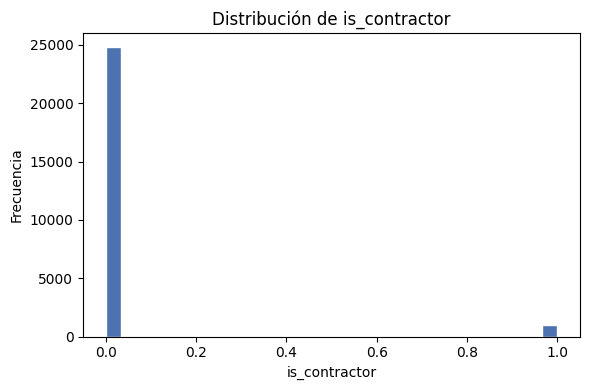

<Figure size 600x400 with 0 Axes>

(array([ 7056.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0., 11741.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,  6956.]),
 array([1.        , 1.06666667, 1.13333333, 1.2       , 1.26666667,
        1.33333333, 1.4       , 1.46666667, 1.53333333, 1.6       ,
        1.66666667, 1.73333333, 1.8       , 1.86666667, 1.93333333,
        2.        , 2.06666667, 2.13333333, 2.2       , 2.26666667,
        2.33333333, 2.4       , 2.46666667, 2.53333333, 2.6       ,
        2.66666667, 2.73333333, 2.8       , 2.86666667, 2.93333333,
        3.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de prior_authorizations_required')

Text(0.5, 0, 'prior_authorizations_required')

Text(0, 0.5, 'Frecuencia')

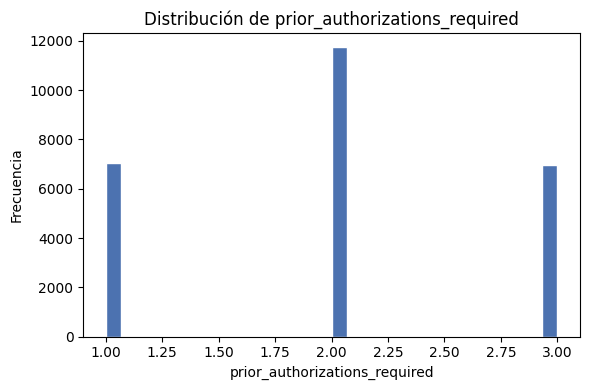

<Figure size 600x400 with 0 Axes>

(array([23549.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,  2204.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de had_travel_incidents')

Text(0.5, 0, 'had_travel_incidents')

Text(0, 0.5, 'Frecuencia')

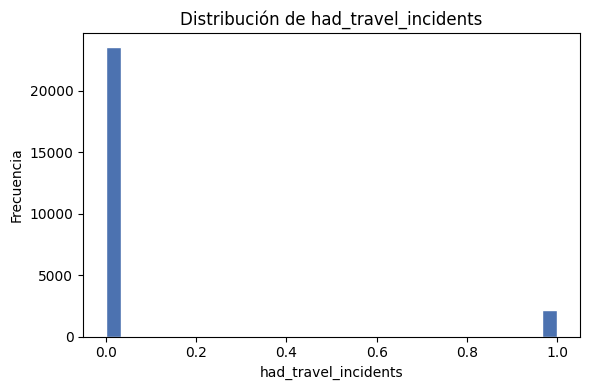

<Figure size 600x400 with 0 Axes>

(array([ 161.,  242.,  432.,  603.,  919.,  978.,  942., 1071., 1112.,
         929.,  986.,  995.,  801.,  669.,  588.,  697.,  750.,  758.,
         740.,  776., 1146., 1413., 1435., 1262., 1212., 1028.,  977.,
         936.,  625.,  570.]),
 array([0.01 , 0.043, 0.076, 0.109, 0.142, 0.175, 0.208, 0.241, 0.274,
        0.307, 0.34 , 0.373, 0.406, 0.439, 0.472, 0.505, 0.538, 0.571,
        0.604, 0.637, 0.67 , 0.703, 0.736, 0.769, 0.802, 0.835, 0.868,
        0.901, 0.934, 0.967, 1.   ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de dept_budget_execution_pct')

Text(0.5, 0, 'dept_budget_execution_pct')

Text(0, 0.5, 'Frecuencia')

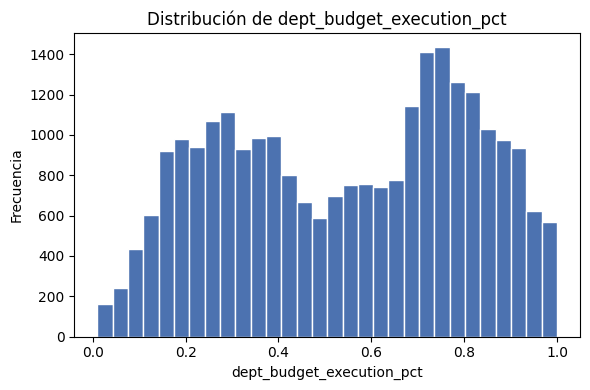

<Figure size 600x400 with 0 Axes>

(array([ 8006.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0., 17747.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de return_trip_included')

Text(0.5, 0, 'return_trip_included')

Text(0, 0.5, 'Frecuencia')

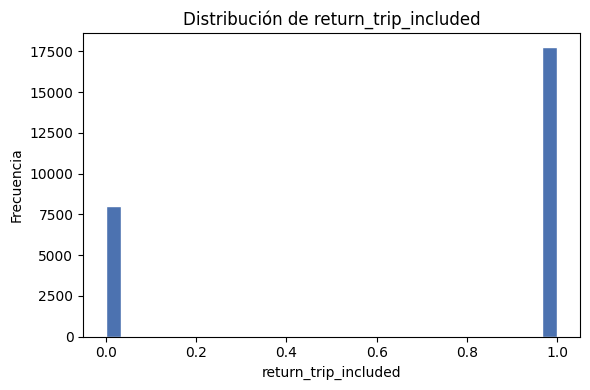

<Figure size 600x400 with 0 Axes>

(array([4.000e+01, 3.097e+03, 0.000e+00, 6.486e+03, 7.623e+03, 0.000e+00,
        4.887e+03, 1.957e+03, 0.000e+00, 5.840e+02, 0.000e+00, 3.310e+02,
        2.280e+02, 0.000e+00, 1.330e+02, 1.190e+02, 0.000e+00, 9.600e+01,
        7.200e+01, 0.000e+00, 5.100e+01, 0.000e+00, 2.000e+01, 1.800e+01,
        0.000e+00, 5.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([ 1.        ,  1.63333333,  2.26666667,  2.9       ,  3.53333333,
         4.16666667,  4.8       ,  5.43333333,  6.06666667,  6.7       ,
         7.33333333,  7.96666667,  8.6       ,  9.23333333,  9.86666667,
        10.5       , 11.13333333, 11.76666667, 12.4       , 13.03333333,
        13.66666667, 14.3       , 14.93333333, 15.56666667, 16.2       ,
        16.83333333, 17.46666667, 18.1       , 18.73333333, 19.36666667,
        20.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de advance_booking_days')

Text(0.5, 0, 'advance_booking_days')

Text(0, 0.5, 'Frecuencia')

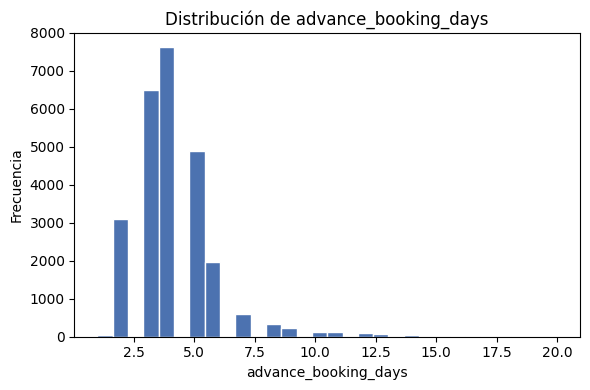

<Figure size 600x400 with 0 Axes>

(array([ 1163.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0., 24590.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de requires_per_diem')

Text(0.5, 0, 'requires_per_diem')

Text(0, 0.5, 'Frecuencia')

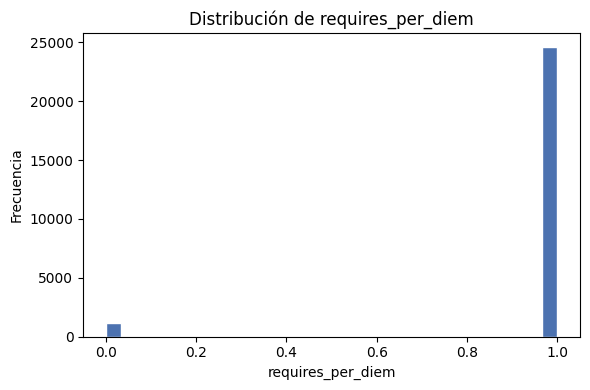

<Figure size 600x400 with 0 Axes>

(array([5.6430e+03, 1.2196e+04, 3.7740e+03, 1.7180e+03, 1.6640e+03,
        3.4100e+02, 1.4800e+02, 7.3000e+01, 4.6000e+01, 4.6000e+01,
        2.2000e+01, 2.4000e+01, 1.8000e+01, 1.8000e+01, 9.0000e+00,
        3.0000e+00, 3.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([      0. ,  250864.2,  501728.4,  752592.6, 1003456.8, 1254321. ,
        1505185.2, 1756049.4, 2006913.6, 2257777.8, 2508642. , 2759506.2,
        3010370.4, 3261234.6, 3512098.8, 3762963. , 4013827.2, 4264691.4,
        4515555.6, 4766419.8, 5017284. , 5268148.2, 5519012.4, 5769876.6,
        6020740.8, 6271605. , 6522469.2, 6773333.4, 7024197.6, 7275061.8,
        7525926. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de daily_allowance_rate')

Text(0.5, 0, 'daily_allowance_rate')

Text(0, 0.5, 'Frecuencia')

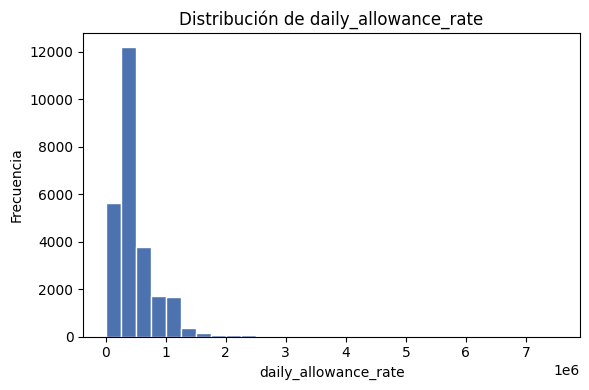

<Figure size 600x400 with 0 Axes>

(array([2.5416e+04, 6.1000e+01, 2.5000e+01, 1.7000e+01, 1.2000e+01,
        2.0000e+01, 9.0000e+00, 2.2000e+01, 9.0000e+00, 2.0000e+01,
        2.0000e+01, 1.3000e+01, 1.1000e+01, 1.4000e+01, 1.9000e+01,
        8.0000e+00, 1.4000e+01, 1.2000e+01, 4.0000e+00, 8.0000e+00,
        4.0000e+00, 7.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00,
        3.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([      0.        ,  110488.96666667,  220977.93333333,
         331466.9       ,  441955.86666667,  552444.83333333,
         662933.8       ,  773422.76666667,  883911.73333333,
         994400.7       , 1104889.66666667, 1215378.63333333,
        1325867.6       , 1436356.56666667, 1546845.53333333,
        1657334.5       , 1767823.46666667, 1878312.43333333,
        1988801.4       , 2099290.36666667, 2209779.33333333,
        2320268.3       , 2430757.26666667, 2541246.23333333,
        2651735.2       , 2762224.16666667, 2872713.13333333,
        2983202.1       , 309369

Text(0.5, 1.0, 'Distribución de allowance_per_km')

Text(0.5, 0, 'allowance_per_km')

Text(0, 0.5, 'Frecuencia')

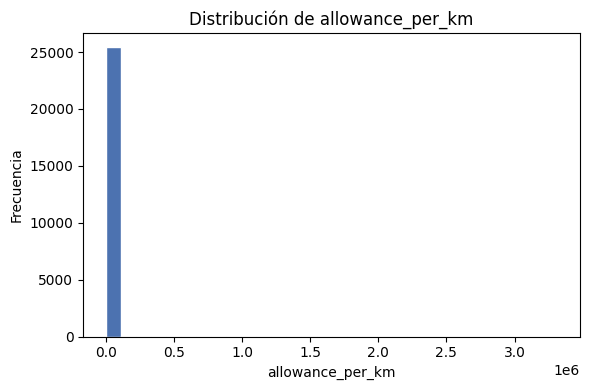

<Figure size 600x400 with 0 Axes>

(array([ 132.,    0., 1021.,    0.,    0., 2711.,    0.,    0., 3365.,
           0., 2797.,    0.,    0., 1242.,    0.,    0., 1864.,    0.,
           0., 1783.,    0., 4117.,    0.,    0., 3364.,    0.,    0.,
        2532.,    0.,  825.]),
 array([ 1.        ,  1.36666667,  1.73333333,  2.1       ,  2.46666667,
         2.83333333,  3.2       ,  3.56666667,  3.93333333,  4.3       ,
         4.66666667,  5.03333333,  5.4       ,  5.76666667,  6.13333333,
         6.5       ,  6.86666667,  7.23333333,  7.6       ,  7.96666667,
         8.33333333,  8.7       ,  9.06666667,  9.43333333,  9.8       ,
        10.16666667, 10.53333333, 10.9       , 11.26666667, 11.63333333,
        12.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de travel_month')

Text(0.5, 0, 'travel_month')

Text(0, 0.5, 'Frecuencia')

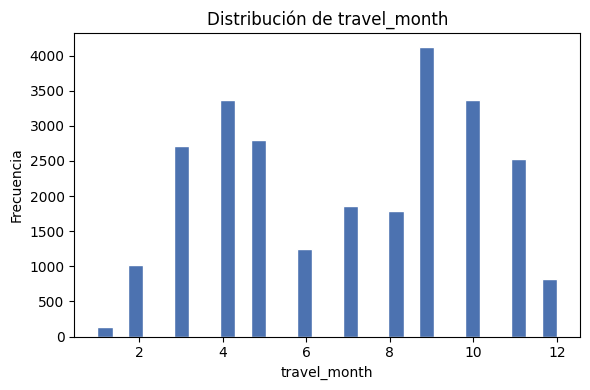

<Figure size 600x400 with 0 Axes>

(array([3864.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 7404.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 7764.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 6721.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
        2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5,
        3.6, 3.7, 3.8, 3.9, 4. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de travel_quarter')

Text(0.5, 0, 'travel_quarter')

Text(0, 0.5, 'Frecuencia')

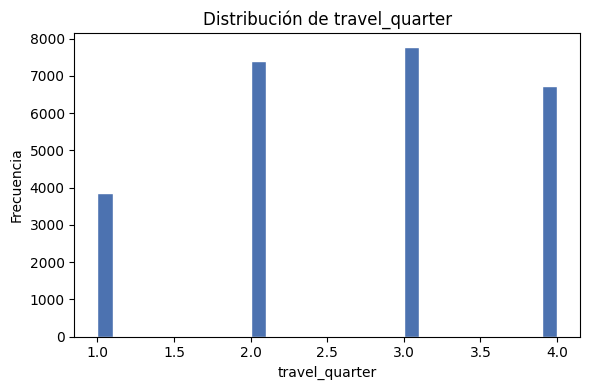

<Figure size 600x400 with 0 Axes>

(array([5370.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 6678.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 7128.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 6577.]),
 array([2022. , 2022.1, 2022.2, 2022.3, 2022.4, 2022.5, 2022.6, 2022.7,
        2022.8, 2022.9, 2023. , 2023.1, 2023.2, 2023.3, 2023.4, 2023.5,
        2023.6, 2023.7, 2023.8, 2023.9, 2024. , 2024.1, 2024.2, 2024.3,
        2024.4, 2024.5, 2024.6, 2024.7, 2024.8, 2024.9, 2025. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de travel_year')

Text(0.5, 0, 'travel_year')

Text(0, 0.5, 'Frecuencia')

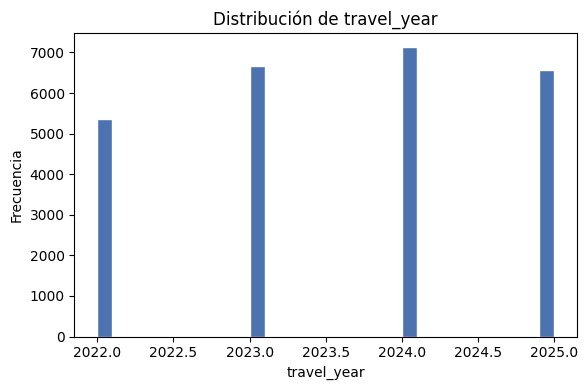

<Figure size 600x400 with 0 Axes>

(array([22396.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,  3357.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de is_fiscal_year_end')

Text(0.5, 0, 'is_fiscal_year_end')

Text(0, 0.5, 'Frecuencia')

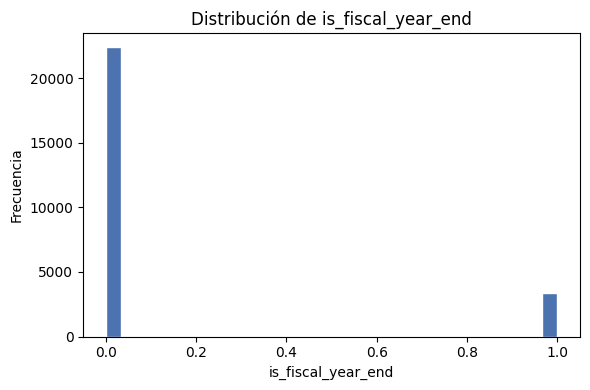

<Figure size 600x400 with 0 Axes>

(array([18164.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,  7589.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de is_weekend_departure')

Text(0.5, 0, 'is_weekend_departure')

Text(0, 0.5, 'Frecuencia')

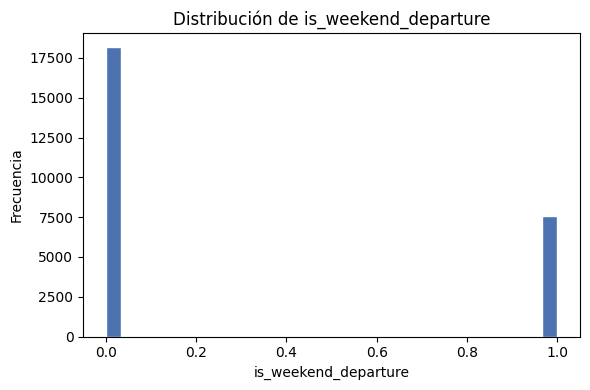

<Figure size 600x400 with 0 Axes>

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.1230e+03,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 9.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.1646e+04, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.1960e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.7780e+03]),
 array([0.5       , 0.61666667, 0.73333333, 0.85      , 0.96666667,
        1.08333333, 1.2       , 1.31666667, 1.43333333, 1.55      ,
        1.66666667, 1.78333333, 1.9       , 2.01666667, 2.13333333,
        2.25      , 2.36666667, 2.48333333, 2.6       , 2.71666667,
        2.83333333, 2.95      , 3.06666667, 3.18333333, 3.3       ,
        3.41666667, 3.53333333, 3.65      , 3.76666667, 3.88333333,
        4.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de position_seniority_index')

Text(0.5, 0, 'position_seniority_index')

Text(0, 0.5, 'Frecuencia')

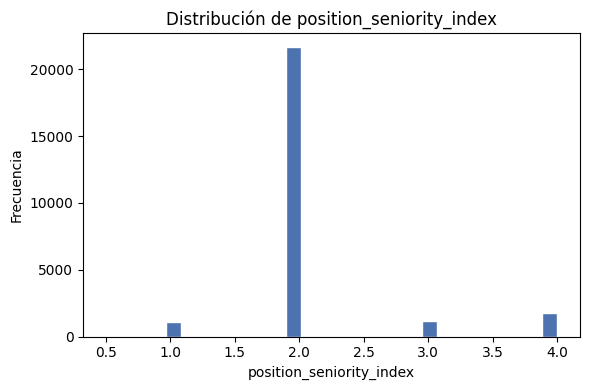

<Figure size 600x400 with 0 Axes>

(array([  133.,     0.,     0.,     0.,     0.,   453.,   199.,     0.,
            0.,   398.,     0.,     0.,     0.,   247.,     0.,     0.,
            0.,     0.,     0.,   498.,     0.,   123.,     0.,     0.,
        15632.,     0.,  7749.,     0.,     0.,   321.]),
 array([      0.  ,   45023.68,   90047.36,  135071.04,  180094.72,
         225118.4 ,  270142.08,  315165.76,  360189.44,  405213.12,
         450236.8 ,  495260.48,  540284.16,  585307.84,  630331.52,
         675355.2 ,  720378.88,  765402.56,  810426.24,  855449.92,
         900473.6 ,  945497.28,  990520.96, 1035544.64, 1080568.32,
        1125592.  , 1170615.68, 1215639.36, 1260663.04, 1305686.72,
        1350710.4 ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de purpose_expense_profile')

Text(0.5, 0, 'purpose_expense_profile')

Text(0, 0.5, 'Frecuencia')

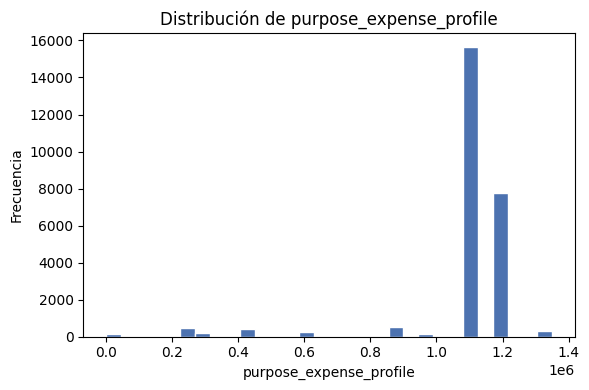

<Figure size 600x400 with 0 Axes>

(array([23947.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,  1806.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de is_multi_destination')

Text(0.5, 0, 'is_multi_destination')

Text(0, 0.5, 'Frecuencia')

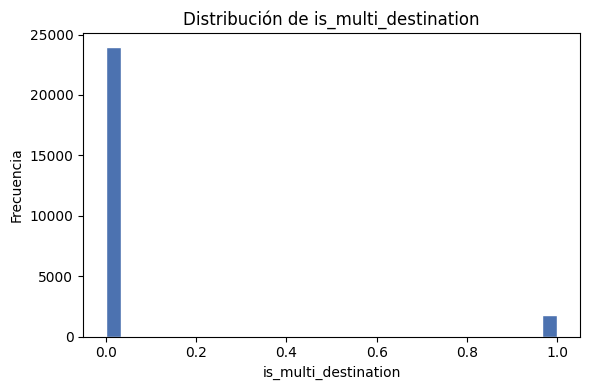

<Figure size 600x400 with 0 Axes>

(array([4.902e+03, 5.147e+03, 5.077e+03, 4.069e+03, 3.531e+03, 1.550e+03,
        7.580e+02, 3.750e+02, 1.700e+02, 6.400e+01, 4.400e+01, 2.600e+01,
        1.800e+01, 1.100e+01, 6.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([       0.        ,   373991.26666667,   747982.53333333,
         1121973.8       ,  1495965.06666667,  1869956.33333333,
         2243947.6       ,  2617938.86666667,  2991930.13333333,
         3365921.4       ,  3739912.66666667,  4113903.93333333,
         4487895.2       ,  4861886.46666667,  5235877.73333333,
         5609869.        ,  5983860.26666667,  6357851.53333333,
         6731842.8       ,  7105834.06666667,  7479825.33333333,
         7853816.6       ,  8227807.86666667,  8601799.13333333,
         8975790.4       ,  9349781.66666667,  9723772.93333333,
        10097764.2       , 10471755.4666666

Text(0.5, 1.0, 'Distribución de multi_dest_cost_ratio')

Text(0.5, 0, 'multi_dest_cost_ratio')

Text(0, 0.5, 'Frecuencia')

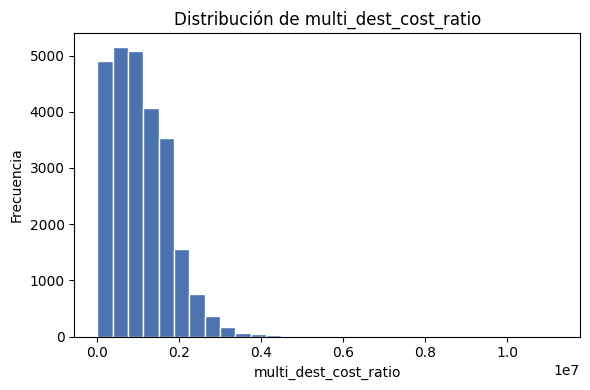

<Figure size 600x400 with 0 Axes>

(array([1.195e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 4.000e+00, 8.000e+00, 1.300e+01, 2.000e+01,
        3.900e+01, 9.300e+01, 5.410e+02, 6.230e+02, 1.014e+03, 1.463e+03,
        4.368e+03, 6.989e+03, 7.509e+03, 1.707e+03, 1.600e+02, 5.000e+00]),
 array([ 0.        ,  0.54110617,  1.08221233,  1.6233185 ,  2.16442467,
         2.70553083,  3.246637  ,  3.78774317,  4.32884933,  4.8699555 ,
         5.41106167,  5.95216783,  6.493274  ,  7.03438017,  7.57548633,
         8.1165925 ,  8.65769867,  9.19880483,  9.739911  , 10.28101717,
        10.82212333, 11.3632295 , 11.90433567, 12.44544183, 12.986548  ,
        13.52765417, 14.06876033, 14.6098665 , 15.15097267, 15.69207883,
        16.233185  ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de log_total_allowance')

Text(0.5, 0, 'log_total_allowance')

Text(0, 0.5, 'Frecuencia')

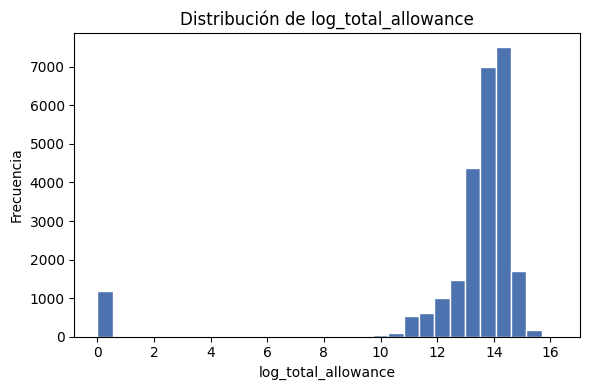

In [ ]:
# Distribucion de cada variable numerica (forma, sesgo, valores extremos)
columnas_num = num_auto

for col in columnas_num:
    plt.figure(figsize=(6, 4))
    plt.hist(
        registraduriaDataset[col].dropna(),
        bins=30,
        color="#4C72B0",
        edgecolor="white"
    )
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

Como podemos observar todas las variables categoricas estan notablemente desbalanceadas, salvo spending_tier:

Omitidas por tener demasiados valores distintos: ['full_date', 'city_destination_main']


<Axes: ylabel='purpose'>

Text(0.5, 1.0, 'purpose')

Text(0.5, 0, '')

Text(0, 0.5, '')

...

Text(0, 0.5, '')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

Text(0.5, 0.98, 'Distribucion de las variables categoricas')

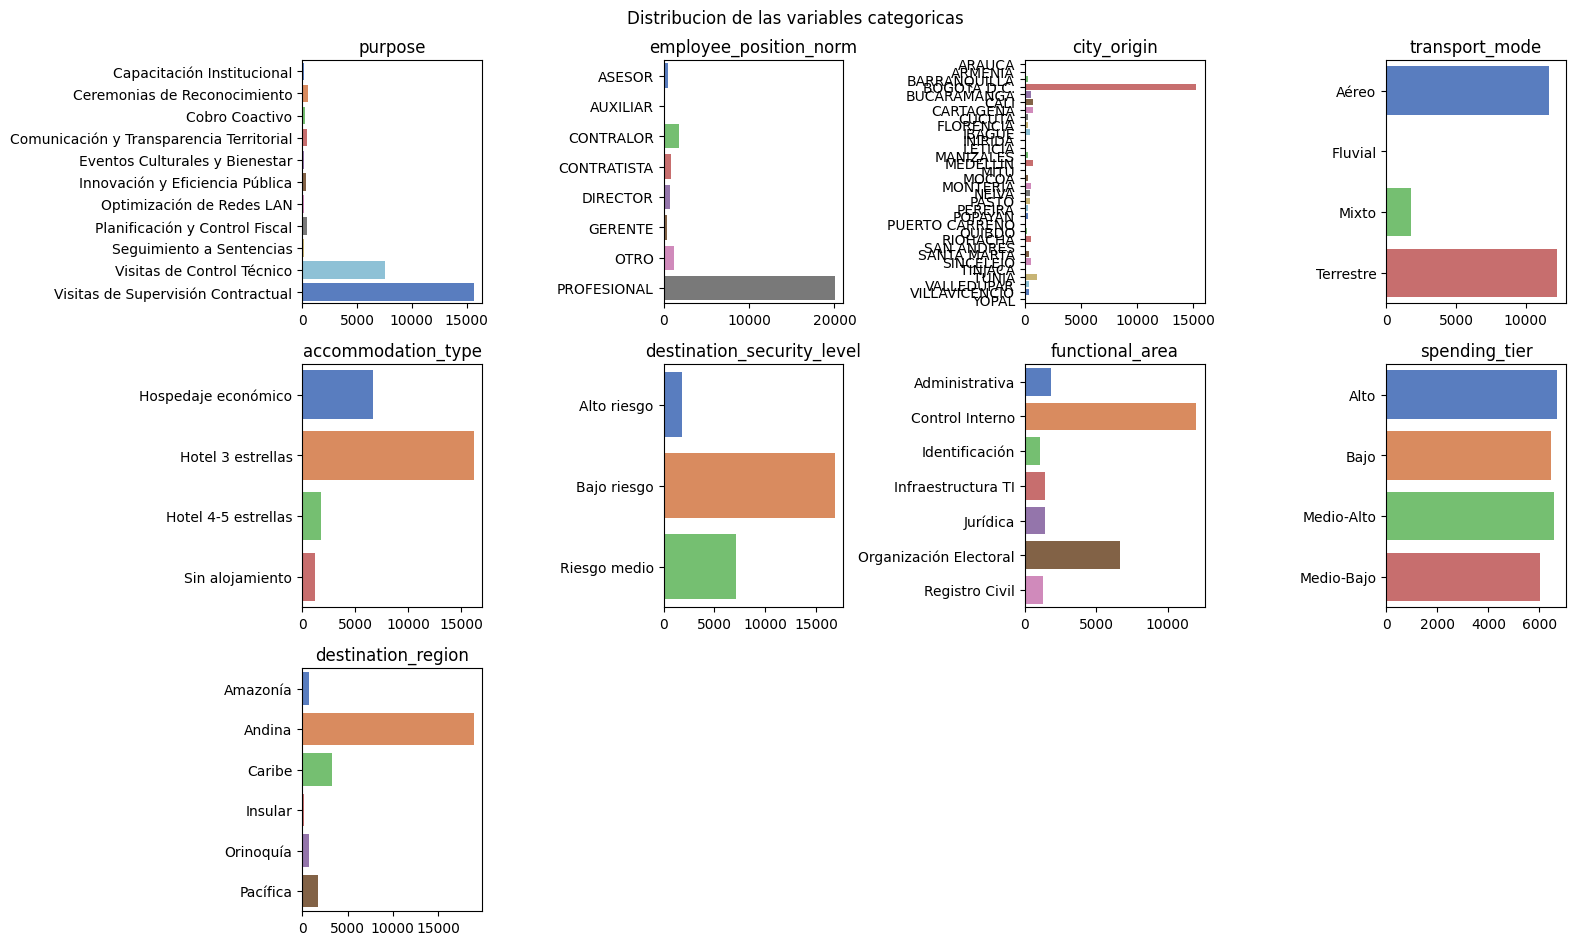

In [ ]:
# Distribucion de las categoricas. Solo graficamos las de cardinalidad manejable:
# una columna con demasiados valores distintos suele ser un ID o un numero disfrazado.
UMBRAL_CARDINALIDAD = 70
cat_graficar = [c for c in cat_auto if registraduriaDataset[c].nunique() <= UMBRAL_CARDINALIDAD]
cat_omitidas = [c for c in cat_auto if registraduriaDataset[c].nunique() > UMBRAL_CARDINALIDAD]
print("Omitidas por tener demasiados valores distintos:", cat_omitidas)

ncols = 4
nrows = int(np.ceil(len(cat_graficar) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, cat_graficar):
    conteo = registraduriaDataset[col].value_counts()
    sns.barplot(x=conteo.values, y=conteo.index, ax=ax, hue=conteo.index, legend=False, palette="muted")
    ax.set_title(col); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes[len(cat_graficar):]:
    ax.axis("off")
fig.suptitle("Distribucion de las variables categoricas")
fig.tight_layout()
plt.show()

## 2.5. Correlación entre las variables
Variables con correlación:

| Variable 1                | Variable 2               | Correlación |
| ------------------------- | ------------------------ | ----------- |
| dept_budget_execution_pct | travel_month             | **0.99**    |
| dept_budget_execution_pct | travel_quarter           | **0.95**    |
| travel_month              | travel_quarter           | **0.96**    |
| position_level            | position_seniority_index | **-0.95**   |
| destination_count         | is_multi_destination     | **0.86**    |
| total_travel_allowance    | multi_dest_cost_ratio    | **0.94**    |
| total_travel_allowance        | prior_authorizations_required | 0.56        |
| total_travel_allowance        | daily_allowance_rate          | 0.53        |
| total_travel_allowance        | log_total_allowance           | 0.53        |
| daily_allowance_rate          | multi_dest_cost_ratio         | 0.54        |
| prior_authorizations_required | multi_dest_cost_ratio         | 0.54        |
| travel_month                  | is_fiscal_year_end            | 0.55        |
| travel_quarter                | is_fiscal_year_end            | 0.50        |

Variables con correlación que son derivadas de otras variables:

| Variable 1                  | Variable 2                 | Correlación |
| --------------------------- | -------------------------- | ----------- |
| `travel_month`              | `travel_quarter`           | 0.96        |
| `dept_budget_execution_pct` | `travel_month`             | 0.99        |
| `dept_budget_execution_pct` | `travel_quarter`           | 0.95        |
| `position_level`            | `position_seniority_index` | -0.95       |
| `destination_count`         | `is_multi_destination`     | 0.86        |
| `total_travel_allowance`    | `multi_dest_cost_ratio`    | 0.94        |
| `total_travel_allowance`    | `log_total_allowance`      | 0.53        |



<Axes: >

Text(0.5, 1.0, 'Correlacion entre variables numericas')

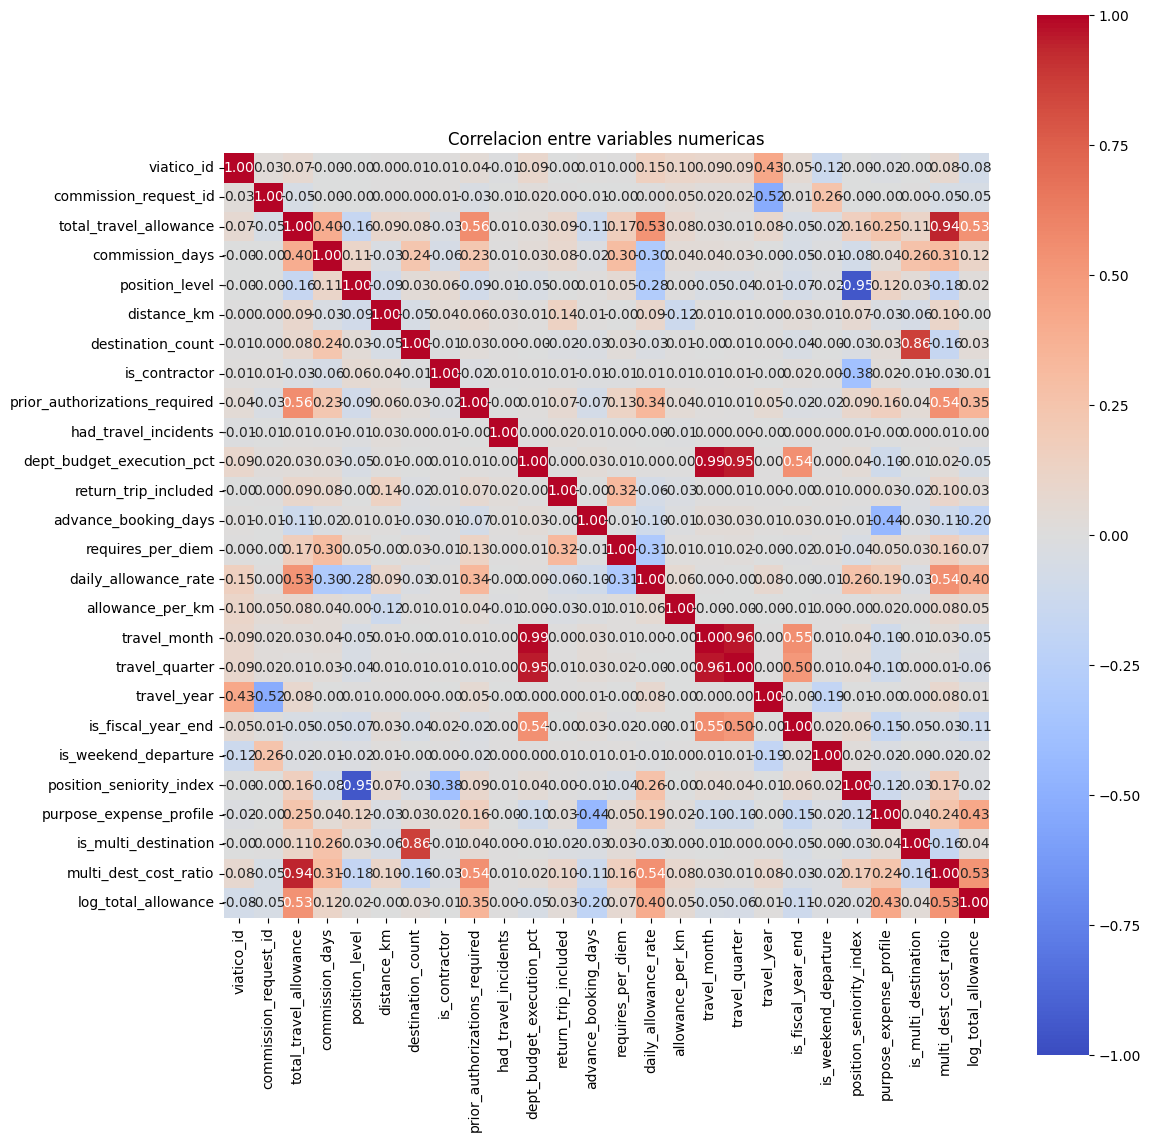

In [ ]:
# Correlacion entre variables numericas (-1 a 1). Rojo = se mueven juntas; azul = en sentido opuesto.
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(registraduriaDataset[num_auto].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlacion entre variables numericas")
fig.tight_layout()
plt.show()

## 2.6. Valores faltantes (y en nuestro caso valores financieros y de distancias que son iguales a 0)



In [ ]:
## Contamos cuantos valores faltan en cada columna: en total y en porcentaje
faltantes = registraduriaDataset.isnull().sum()
faltantes_pct = (faltantes / len(registraduriaDataset) * 100).round(1)

## Identificar el procentaje de las columans con 0 para las probables variables objetico
registraduriaDataset[[
    "total_travel_allowance", "distance_km", "daily_allowance_rate",
    "allowance_per_km", "multi_dest_cost_ratio", "log_total_allowance"
]].eq(0).agg(['sum', 'mean']).T.mul([1, 100]).round(1).set_axis(['total_ceros', 'porcentaje_ceros (%)'], axis=1)

## Mostramos solo las columnas que SI tienen huecos, ordenadas de mayor a menor
resumen = pd.DataFrame({"Faltantes": faltantes, "%": faltantes_pct})
resumen[resumen["Faltantes"] > 0].sort_values("Faltantes", ascending=False)

,total_ceros,porcentaje_ceros (%)
total_travel_allowance,1195.0,4.6
distance_km,375.0,1.5
daily_allowance_rate,1195.0,4.6
allowance_per_km,1195.0,4.6
multi_dest_cost_ratio,1195.0,4.6
log_total_allowance,1195.0,4.6


,Faltantes,%


### Revision de ceros en la columna total_travel_allowance:

Evaluamos los ceros que contiene esta columna para ver si existe una dinamica especifica relacionada a la existencia de dichos valores (por ejemplo que las visitas sean de menos de un día o que sean a la misma ciudad).

Se encuentra que hay 1195 filas cuyo gasto de viaje es cero y que son comisiones de varios dias y con origenes y destinos diferentes, por lo tanto lo consideramos un error que podríamos remediar **imputando los datos con alguna de las tecnicas aprendidas en clase**.

Es importante resaltar que estos valores en cero corresponden a los valores en cero evidenciados en las columnas:
- *daily_allowance_rate*
- *allowance_per_km*
- *multi_dest_cost_ratio*
- *log_total_travel_allowance*

In [ ]:
reg_ceros = registraduriaDataset[registraduriaDataset['total_travel_allowance'] == 0]
reg_ceros

,viatico_id,commission_request_id,total_travel_allowance,purpose,full_date,commission_days,employee_position_norm,position_level,city_origin,city_destination_main,...,travel_year,is_fiscal_year_end,is_weekend_departure,spending_tier,destination_region,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
35,24288,2412312,0,Visitas de Supervisión Contractual,2022-02-05,1.5,PROFESIONAL,3,BOGOTA D.C.,PAZ - ARIPORO,...,2022,0,1,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
43,22382,2410406,0,Visitas de Supervisión Contractual,2022-02-06,4.5,PROFESIONAL,3,BOGOTA D.C.,IBAGUE,...,2022,0,1,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
52,16666,2404690,0,Visitas de Supervisión Contractual,2022-02-07,2.5,PROFESIONAL,3,BOGOTA D.C.,SANTA MARTA,...,2022,0,0,Bajo,Caribe,2.0,1107881.0,0,0.0,0.0
56,25287,2413311,0,Visitas de Supervisión Contractual,2022-02-08,2.5,PROFESIONAL,3,BOGOTA D.C.,VILLETA,...,2022,0,0,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
57,21752,2409776,0,Visitas de Supervisión Contractual,2022-02-09,1.5,PROFESIONAL,3,NEIVA,SABANALARGA,...,2022,0,0,Bajo,Caribe,2.0,1107881.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25734,24440,2412464,0,Visitas de Control Técnico,2025-12-26,9.0,PROFESIONAL,3,BOGOTA D.C.,TABIO,...,2025,1,0,Bajo,Andina,2.0,1183522.0,0,0.0,0.0
25737,19863,2407887,0,Visitas de Supervisión Contractual,2025-12-27,2.5,PROFESIONAL,3,BOGOTA D.C.,PAEZ,...,2025,1,1,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
25740,18672,2406696,0,Visitas de Supervisión Contractual,2025-12-28,3.5,OTRO,3,POPAYAN,VALLEDUPAR,...,2025,1,1,Bajo,Caribe,2.0,1107881.0,0,0.0,0.0
25743,20901,2408925,0,Visitas de Control Técnico,2025-12-29,1.5,CONTRALOR,1,BOGOTA D.C.,MONTERIA,...,2025,1,0,Bajo,Caribe,4.0,1183522.0,0,0.0,0.0


### Revision de ceros en la columna distance_km:

Evaluamos los ceros que contiene esta columna para ver si existe una dinamica especifica relacionada a la existencia de dichos valores.

Se encuentra que hay 375 filas cuyo distancia entre las ciudades de origen y destino es cero y que consideramos un error que podríamos remediar **imputando los datos con alguna de las tecnicas aprendidas en clase**.


In [ ]:
reg_ceros = registraduriaDataset[registraduriaDataset['distance_km'] == 0]
reg_ceros

,viatico_id,commission_request_id,total_travel_allowance,purpose,full_date,commission_days,employee_position_norm,position_level,city_origin,city_destination_main,...,travel_year,is_fiscal_year_end,is_weekend_departure,spending_tier,destination_region,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
400,22343,2410367,1868481,Visitas de Supervisión Contractual,2022-03-11,3.5,PROFESIONAL,3,BOGOTA D.C.,SAN ONOFRE,...,2022,0,0,Alto,Andina,2.0,1107881.0,0,1868481.0,14.440637
440,24318,2412342,1608113,Visitas de Supervisión Contractual,2022-03-12,5.5,PROFESIONAL,3,BOGOTA D.C.,EL - DE BOLIVAR,...,2022,0,1,Alto,Andina,2.0,1107881.0,0,1608113.0,14.290573
448,25854,2413878,1834567,Visitas de Control Técnico,2022-03-13,2.5,PROFESIONAL,3,BOGOTA D.C.,PIOJO,...,2022,0,1,Alto,Andina,2.0,1183522.0,0,1834567.0,14.422320
490,23703,2411727,1042273,Visitas de Control Técnico,2022-03-17,2.5,PROFESIONAL,3,MEDELLIN,EL COPEY,...,2022,0,0,Medio-Alto,Andina,2.0,1183522.0,0,1042273.0,13.856915
592,22352,2410376,1781906,Visitas de Supervisión Contractual,2022-03-22,1.5,PROFESIONAL,3,BOGOTA D.C.,BUENAVENTURA,...,2022,0,0,Alto,Pacífica,2.0,1107881.0,0,1781906.0,14.393195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25230,21115,2409139,258072,Comunicación y Transparencia Territorial,2025-11-17,4.5,CONTRATISTA,3,BOGOTA D.C.,S.JUAN NEPOMUCENO,...,2025,1,0,Bajo,Andina,1.0,441603.5,0,258072.0,12.460998
25323,16830,2404854,1894268,Visitas de Control Técnico,2025-11-19,2.0,CONTRATISTA,3,PEREIRA,EL COPEY,...,2025,1,0,Alto,Andina,1.0,1183522.0,0,1894268.0,14.454344
25383,16793,2404817,1311098,Visitas de Control Técnico,2025-11-23,10.0,PROFESIONAL,3,BOGOTA D.C.,GIRON,...,2025,1,1,Medio-Alto,Andina,2.0,1183522.0,0,1311098.0,14.086376
25530,23328,2411352,565989,Visitas de Supervisión Contractual,2025-11-29,1.5,PROFESIONAL,3,RIOHACHA,SAN ONOFRE,...,2025,1,1,Medio-Bajo,Andina,2.0,1107881.0,0,565989.0,13.246332


<Axes: >

Text(0.5, 1.0, 'Mapa de Ceros en Variables Financieras y de Distancia (Azul = 0)')

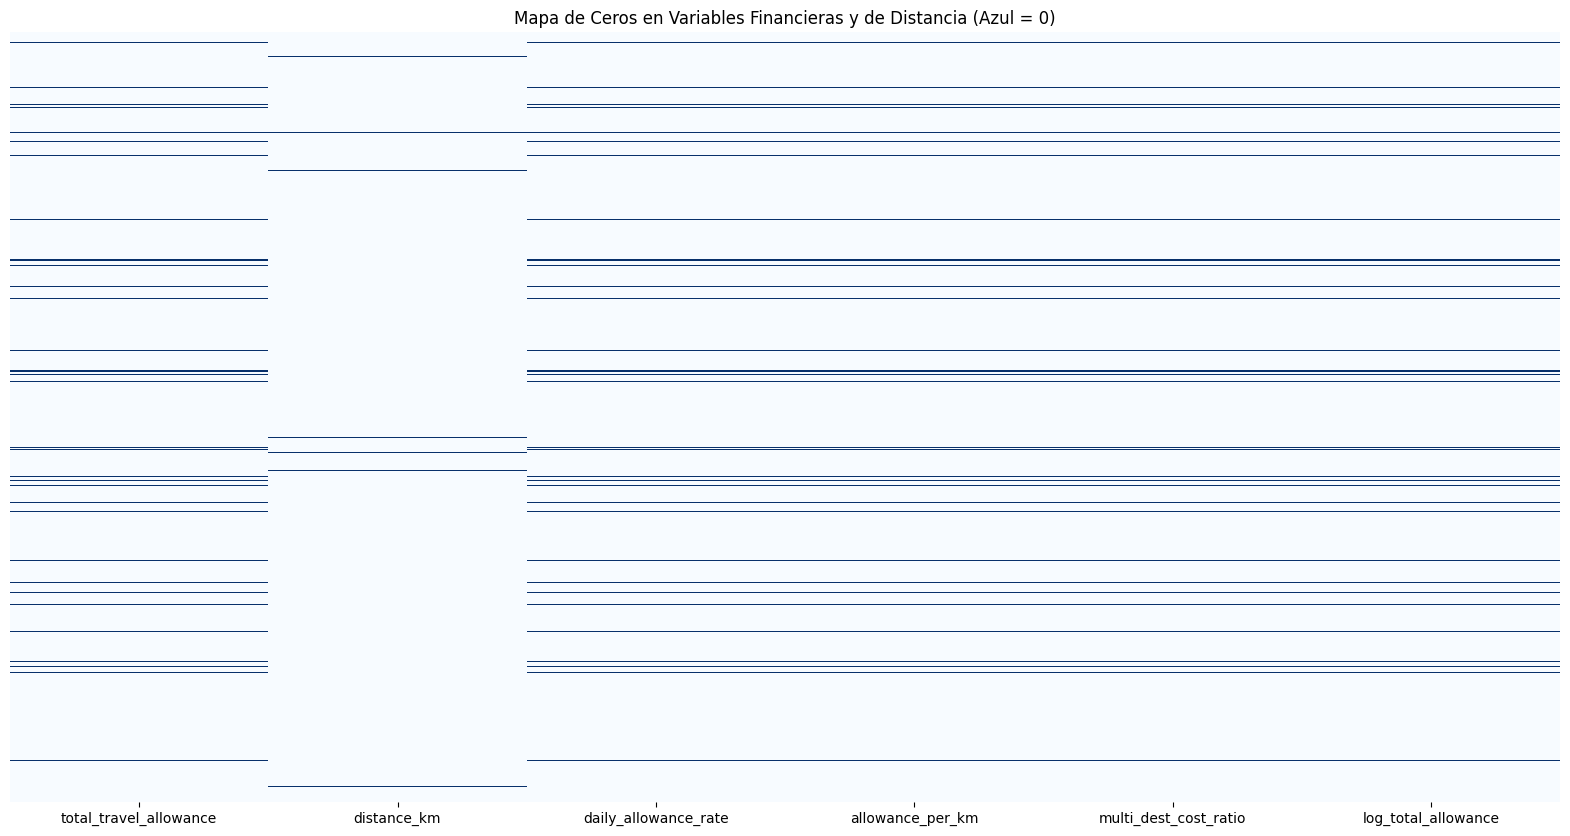

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    registraduriaDataset[[
        "total_travel_allowance", "distance_km", "daily_allowance_rate",
        "allowance_per_km", "multi_dest_cost_ratio", "log_total_allowance"
    ]].eq(0),
    cbar=False,
    cmap="Blues",
    yticklabels=False,
    ax=ax
)

ax.set_title("Mapa de Ceros en Variables Financieras y de Distancia (Azul = 0)")
plt.show()

# 3. Limpieza antes de la división del dataset

In [ ]:
## Descartar variables de identificación
registraduriaLimpio = registraduriaDataset.drop(columns=["viatico_id", "commission_request_id"])

In [ ]:
## Llenar con valores nulos aquellas columnas con ceros invalidos

columnas_con_ceros_invalidos = [
    'total_travel_allowance',
    'distance_km',
    'daily_allowance_rate',
    'allowance_per_km',
    'multi_dest_cost_ratio',
    'log_total_allowance'
]

registraduriaLimpio[columnas_con_ceros_invalidos] = (
    registraduriaLimpio[columnas_con_ceros_invalidos]
    .replace(0, np.nan)
)

# 4. Division del dataset para el modelo de Clasificación

In [ ]:
# Seleccion de variables: variable objetivo y variables independientes, predictoras o features

# Variable objetivo
y = registraduriaLimpio['purpose']

# Variables predictoras
predictoras = [c for c in registraduriaLimpio.columns if c != 'purpose']
X = registraduriaLimpio[predictoras]

# Verificar si la variable objetivo tiene valores vacios
print("NaN en y:", y.isna().sum())
print(y.value_counts(dropna=False))

NaN en y: 0
purpose
Visitas de Supervisión Contractual          15632
Visitas de Control Técnico                   7545
Ceremonias de Reconocimiento                  498
Planificación y Control Fiscal                453
Comunicación y Transparencia Territorial      398
Innovación y Eficiencia Pública               321
Cobro Coactivo                                247
Optimización de Redes LAN                     204
Eventos Culturales y Bienestar                199
Capacitación Institucional                    133
Seguimiento a Sentencias                      123
Name: count, dtype: int64


In [ ]:
# Division de dataset para CLASIFICACION
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,          # 20% de los datos para prueba
    random_state = 42,
    stratify = y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba       : {X_test.shape[0]} filas")

Entrenamiento: 20602 filas
Prueba       : 5151 filas
